Data shape: (1797, 64)
Image shape: (1797, 8, 8)
Target names: [0 1 2 3 4 5 6 7 8 9]


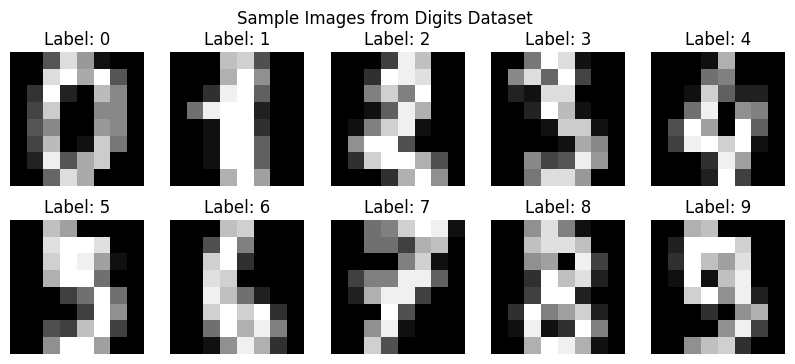

target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


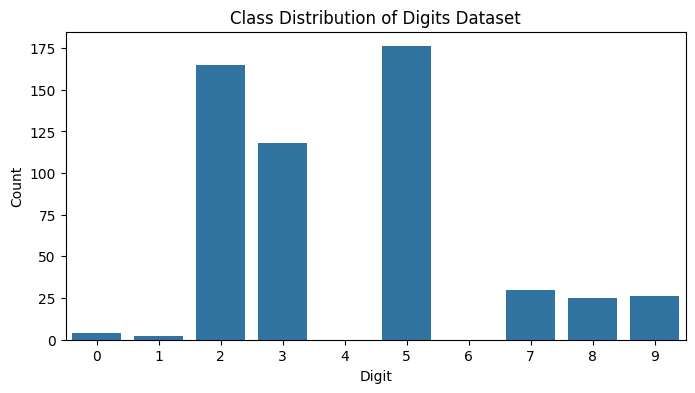

C:\Users\Fe\.conda\envs\ml_lab\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
 

                 Model  Accuracy
0  Logistic Regression  0.972222
1                  KNN  0.963889
3        Random Forest  0.961111
2        Decision Tree  0.811111


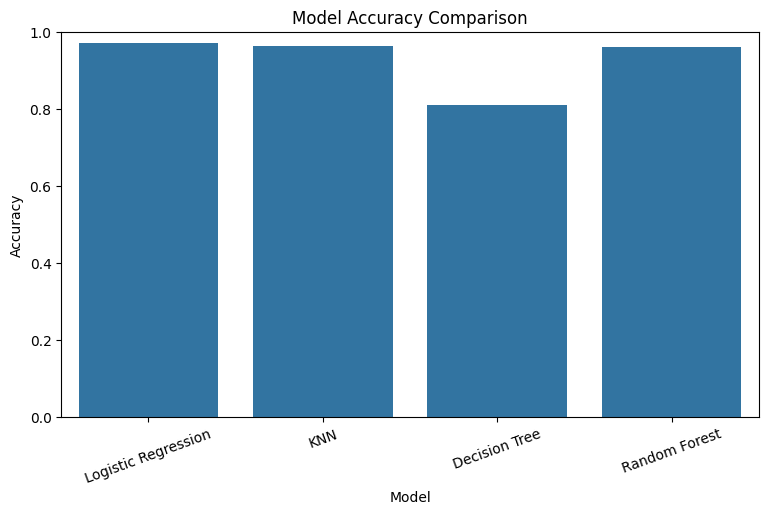

Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Best cross-validation score: 0.9770180023228804
Best Model Test Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



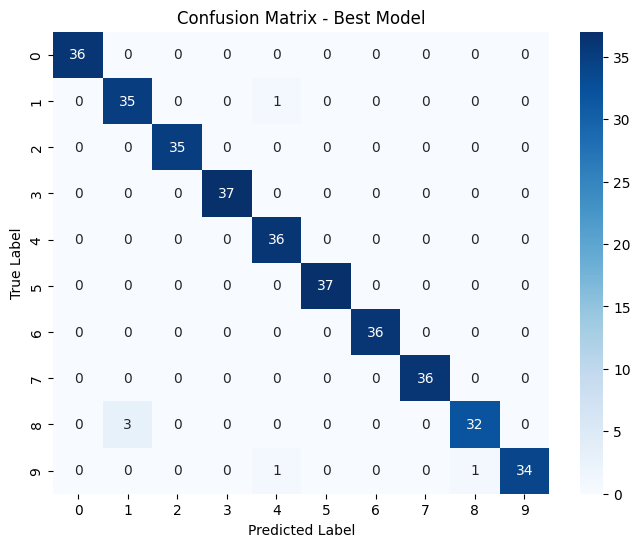

Number of wrong predictions: 6


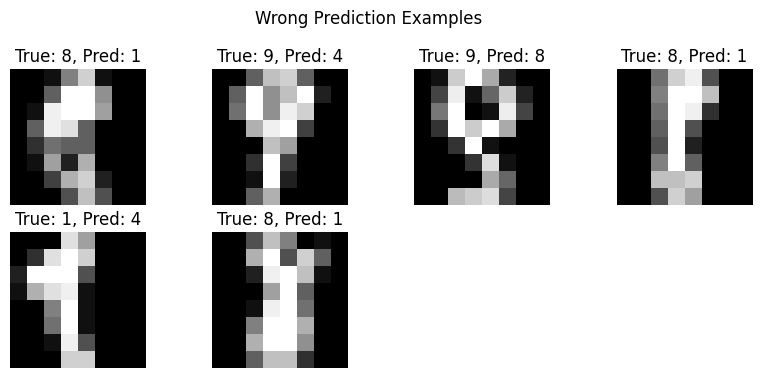

Model saved as best_digits_model.pkl
True label: 5
Predicted label: 5


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

digits = load_digits()
X = digits.data
y = digits.target

print("Data shape:", X.shape)
print("Image shape:", digits.images.shape)
print("Target names:", digits.target_names)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")
plt.suptitle("Sample Images from Digits Dataset")
plt.show()

df = pd.DataFrame(X)
df["target"] = y
print(df["target"].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="target")
plt.title("Class Distribution of Digits Dataset")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
logistic_pipeline.fit(X_train, y_train)
accuracy_logistic = accuracy_score(y_test, logistic_pipeline.predict(X_test))

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)
accuracy_knn = accuracy_score(y_test, knn_pipeline.predict(X_test))

tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)
accuracy_tree = accuracy_score(y_test, tree_model.predict(X_test))

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
accuracy_rf = accuracy_score(y_test, rf_model.predict(X_test))

results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_logistic, accuracy_knn, accuracy_tree, accuracy_rf]
})
print(results.sort_values(by="Accuracy", ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print("Best parameters:", knn_grid.best_params_)
print("Best cross-validation score:", knn_grid.best_score_)

best_model = knn_grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Best Model Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

wrong_indices = np.where(y_test != y_pred_best)[0]
print("Number of wrong predictions:", len(wrong_indices))

plt.figure(figsize=(10, 6))
for i, idx in enumerate(wrong_indices[:12]):
    plt.subplot(3, 4, i + 1)
    image = X_test[idx].reshape(8, 8)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred_best[idx]}")
    plt.axis("off")
plt.suptitle("Wrong Prediction Examples")
plt.show()

joblib.dump(best_model, "best_digits_model.pkl")
print("Model saved as best_digits_model.pkl")

loaded_model = joblib.load("best_digits_model.pkl")
sample = X_test[0].reshape(1, -1)
prediction = loaded_model.predict(sample)
print("True label:", y_test[0])
print("Predicted label:", prediction[0])